# Downloading JWST and Euclid data

In [1]:
import requests
from io import BytesIO
from astropy.io import fits
import matplotlib.pyplot as plt

In [2]:
# Replace this with your Dropbox shared link and modify to dl=1 at the end
dropbox_url = "https://www.dropbox.com/scl/fi/ibbxaq0fj9gkodsu0idow/EUC_MER_BGSUB-MOSAIC-NIR-J_TILE[…]Z_00.00.fits?rlkey=i1pnapefx2uj20v7y33lkl3e3&st=egn0es4i&dl=1"
# Stream the FITS file
response = requests.get(dropbox_url)
response.raise_for_status()  # Ensure successful request
# Read FITS file from memory
fits_file = BytesIO(response.content)
hdul = fits.open(fits_file)
# Display FITS file info
hdul.info()
# Access image data
image_data = hdul[0].data
hdul.close()

Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      48   (10200, 10200)   float32   


In [12]:
folder_url = "https://caltech.box.com/s/3ykklf78uj89nm0wrc3tpwkkakpsmjju?dl=1"
response = requests.get(folder_url)
response.raise_for_status()

## Using Dropbox API

In [1]:
import requests
from io import BytesIO
from astropy.io import fits
import matplotlib.pyplot as plt
import dropbox
import numpy as np
import pandas as pd
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D

In [2]:
home = "/Users/emily_ramey"
with open(f"{home}/secrets/dropbox_token") as token_file:
    token = token_file.read()
    dbx = dropbox.Dropbox(token.strip())
dbx

In [3]:
parent_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/AK5SQfnqsfDYbqvUW1WVESI?rlkey=enfshikpl0r0wd8o2nz66i0km&e=1&st=brev767o&dl=0'
jwst_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/ANfH2VisN0vIphVxNIpO_ag/JWST?rlkey=enfshikpl0r0wd8o2nz66i0km&subfolder_nav_tracking=1&st=w3u4yz80&dl=0'
nisp_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/AEiIbqfbMKqh6FRA2YouLHQ/NISP-J?rlkey=enfshikpl0r0wd8o2nz66i0km&subfolder_nav_tracking=1&st=hx3ru322&dl=0'

In [4]:
def get_shared_folder_metadata(url):
    """Get metadata of the shared folder."""
    shared_link = dropbox.files.SharedLink(url=url)
    try:
        folder_metadata = dbx.files_list_folder(path="", shared_link=shared_link)
        return folder_metadata.entries
    except dropbox.exceptions.ApiError as e:
        print(f"Error accessing shared folder: {e}")
        return []

# def download_file(file_path, local_path):
#     """Download a file from Dropbox to local storage."""
#     try:
#         metadata, res = dbx.files_download(path=file_path)
#         with open(local_path, "wb") as f:
#             f.write(res.content)
#             print(f"Downloaded: {file_path} -> {local_path}")
#     except dropbox.exceptions.ApiError as e:
#         print(f"Error downloading {file_path}: {e}")
#         # List and download files

files = get_shared_folder_metadata(jwst_url)

In [6]:
meta, res = dbx.sharing_get_shared_link_file(jwst_url, path='/'+files[0].name)

fits_file = BytesIO(res.content)
hdul = fits.open(fits_file)

# Access image data
image_data = hdul[0].data
image_header = hdul[0].header
hdul.close()

In [7]:
wcs = WCS(image_header)
# N1, N2 = image_data.shape # Data is in Y, X format, so Y axis is 12455 and X axis is 9600
# # Corners for input into pixel_to_world are in X, Y format! (0,0), (9600,0), (0,12455), and (9600,12455)
# corners = np.array([[0, 0], [N1, 0], [0, N2], [N1, N2]])
# print(wcs.array_shape)
# corners_sky = wcs.pixel_to_world(corners[:,1], corners[:,0])
# corners_sky

(12455, 9600)


Set DATE-AVG to '2023-04-29T00:59:18.908' from MJD-AVG.
Set DATE-END to '2024-04-17T18:10:49.417' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     1.572297 from OBSGEO-[XYZ].
Set OBSGEO-H to 1265954850.776 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


<SkyCoord (ICRS): (ra, dec) in deg
    [(150.2769883 , 1.93775646), (150.34805533, 2.13280935),
     (150.12655384, 1.99248633), (150.19760458, 2.18754777)]>

In [8]:
test_coord = wcs.pixel_to_world([9599, 9600,0,1], [12454,12455,0,1])
test_coord, test_coord.contained_by(wcs)

(<SkyCoord (ICRS): (ra, dec) in deg
     [(150.19761455, 2.18752641), (150.19760458, 2.18754777),
      (150.2769883 , 1.93775646), (150.27697834, 1.93777782)]>,
 array([ True, False, False,  True]))

In [9]:
# Load in the catalog
# Path to your FITS file
farmer_cat_path = '../catalog/COSMOS2020_FARMER_R1_v2.2_p3.fits'
classic_cat_path = '../catalog/COSMOS2020_CLASSIC_R1_v2.2_p3.fits'

# Load the FITS file
with fits.open(classic_cat_path) as hdul:
    cat_data = hdul[1].data  # Adjust the HDU index if your data is not in the first extension

len(cat_data)

1720700

In [15]:
# cat_data.columns # Uncomment to see catalog columns

In [11]:
# Cuts
cat_clipped = cat_data[(cat_data.lp_type==0) & \
                       (cat_data.ACS_F814W_MAG < 25) & \
                       (cat_data.ez_z_phot > 0.01) & (cat_data.ez_z_phot < 3.0) & \
                       (cat_data.FLUX_RADIUS < 24) # TODO: make this a function with J&H bands?
                      ]

In [12]:
gal_coords = SkyCoord(cat_clipped['ALPHA_J2000'], cat_clipped['DELTA_J2000'], unit='deg')
idxs = np.where(gal_coords.contained_by(wcs))[0]
in_image = gal_coords[idxs]

In [13]:
in_image[0]

<SkyCoord (ICRS): (ra, dec) in deg
    (150.27454877, 1.93922734)>

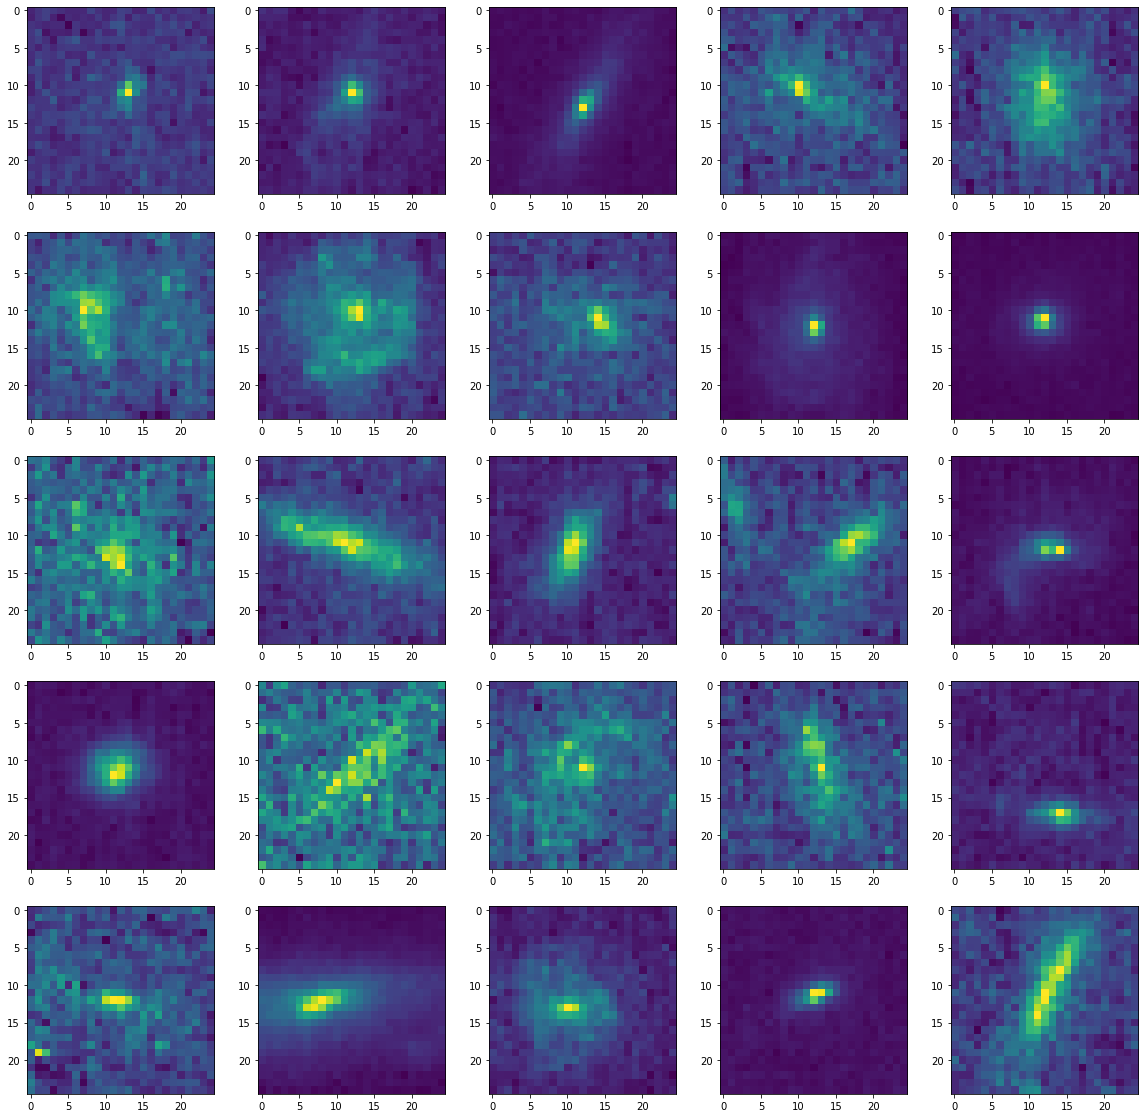

In [14]:
fig, axes = plt.subplots(5, 5, figsize=(20,20))
for i in range(25):
    clip = Cutout2D(image_data, in_image[i], size=25, wcs=wcs, mode='partial', fill_value=0)
    axes.flatten()[i].imshow(clip.data)

In [16]:
# Now to do the same for the Euclid data!
# Problem is how to keep cross-matching when I can't load all the clips in memory at once
# I can either upload the clips and save their names to a pandas dataframe, then match after
#     OR I can not save the clips, wait till they are matched, and then do the clips based on saved filenames
#     All depends on whether we think there is good overlap between the Euclid and JWST images we have
#     (will there be a ton of clips unmatched or will most of them be matched?)

In [17]:
files = get_shared_folder_metadata(nisp_url)

meta, res = dbx.sharing_get_shared_link_file(nisp_url, path='/'+files[0].name)

fits_file = BytesIO(res.content)
hdul = fits.open(fits_file)

# Access image data
image_data = hdul[0].data
image_header = hdul[0].header
hdul.close()

In [19]:
wcs = WCS(image_header)
idxs = np.where(gal_coords.contained_by(wcs))[0]
in_image = gal_coords[idxs]
len(in_image)

8547

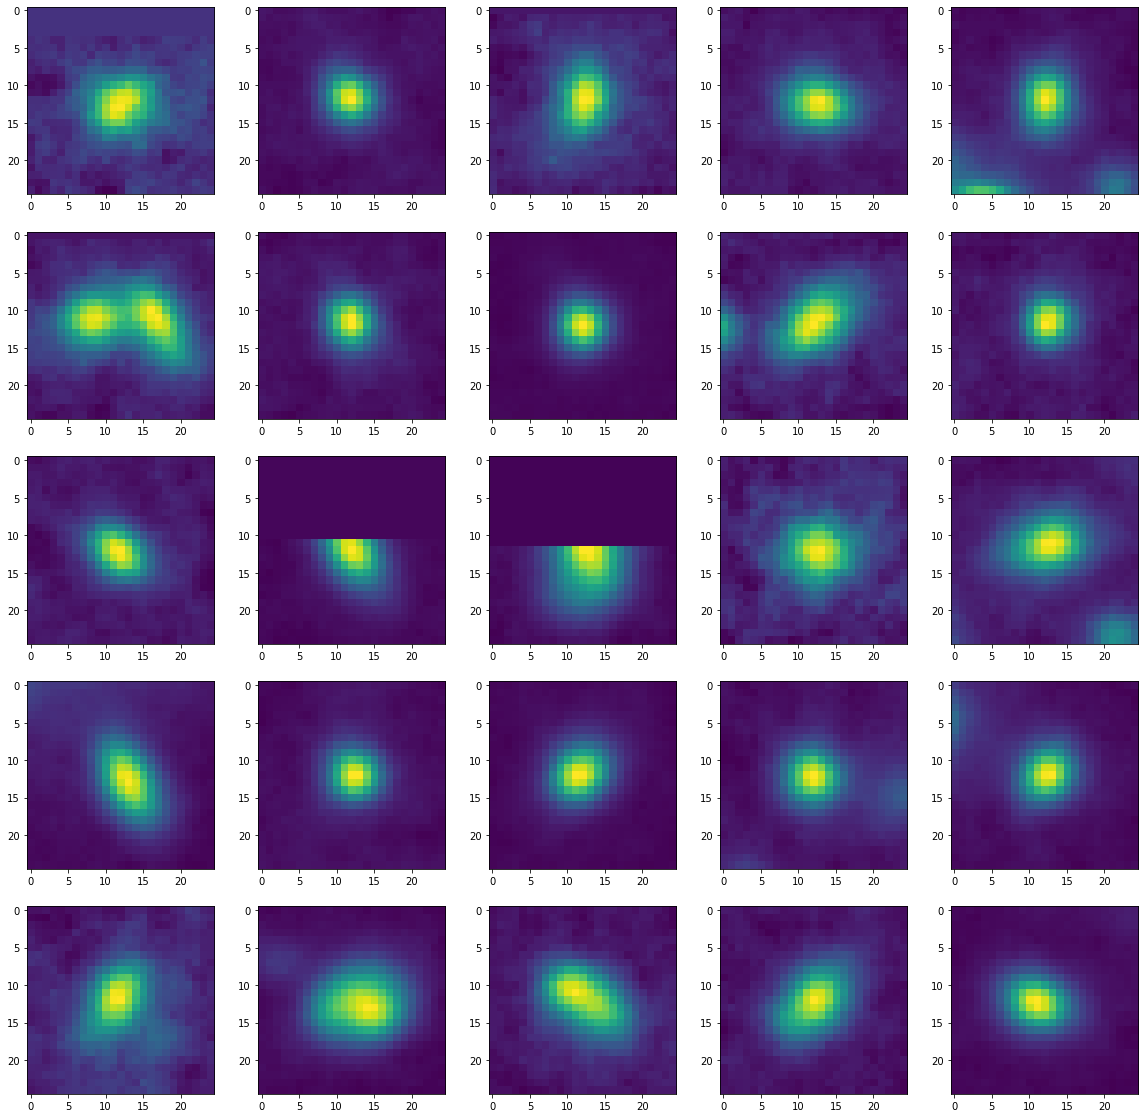

In [20]:
# Question: What size clips do we want? I imagine it'll be based on the pixel scale?
#     Do we need any resampling between Euclid and JWST?
# TODO: figure out how to get the edge / cut off ones out 
#     - can use 'trim' mode and check resulting shape, or catch PartialOverlapError
fig, axes = plt.subplots(5, 5, figsize=(20,20))
for i in range(25):
    clip = Cutout2D(image_data, in_image[i], size=25, wcs=wcs, mode='partial', fill_value=0)
    axes.flatten()[i].imshow(clip.data)